## Bayesian XG Model 
### by Adam Sequeira 
- [reference paper here](https://arxiv.org/abs/2311.13707)

#### Problem Statement 
In football there is a varying scale of richness of tagging data, if paying for third party systems, you can get or generate at a minimum basic (x,y) co-ordinates. From this you have the ability to generate a baseline xG model, by calculating shot_distance and shot_angle. 

One step further would be data that includes features associated with shots, including what body_part was used, was the player under_pressure, the shot technique, the play_pattern (free_kick, penalty etc...), this was standard in statsbomb's open dataset 

One step further than that, has been the release of statsbomb including freeze-frame data as part of their events, this include the x,y position of players off the ball along with other features like the assist_type and assist_height. 

While richer datasets generally produce more accurate xG estimates, the inverse is also true: when fewer features are available, there is greater uncertainty regarding the true probability of a goal. Traditional xG models, commonly implemented using logistic regression or machine learning classifiers, typically return a single point estimate for each shot. Although useful, these point estimates do not communicate how certain the model is about its prediction.

This creates a challenge when comparing xG values generated from different data providers, competitions, or historical datasets that contain varying levels of information. Two shots may receive the same predicted xG value despite one being estimated from rich contextual data and the other from only basic location data. Intuitively, confidence in these estimates should differ.

Bayesian modeling provides a natural framework for addressing this problem. Rather than producing a single probability estimate, Bayesian models generate a posterior distribution over the goal probability. This distribution quantifies both the estimated probability of scoring and the uncertainty surrounding that estimate. When informative features are unavailable, posterior distributions can widen to reflect increased uncertainty. Conversely, when richer contextual information is available, the posterior distribution can become more concentrated, indicating greater confidence in the prediction.

#### Why is this Relevant? 
The ability to quantify uncertainty is valuable for both practitioners and researchers. In football analytics, model outputs are often used to evaluate player/match shot quality. In recruitment, players go through different systems with different levels of richness in their data. 

A probabilistic framework also allows analysts to:

Distinguish between aleatoric uncertainty (inherent randomness in goal scoring) and epistemic uncertainty (uncertainty arising from limited information).
Compare xG estimates across datasets with different levels of feature richness.
Incorporate uncertainty directly into downstream models and decision-making processes.
Produce more robust estimates in situations with sparse data or rare events.


#### Goal 
- Generate one size fits all bayesian xg model that provides the following
    - posterior distribution of outcomes instead of standard point estimates 
    - able to factor in error for different tagging systems. 

In [2]:
import nutpie
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from pathlib import Path

## Proposed Bayesian Model

Let each shot $i \in \{1, \ldots, N\}$ have observed goal outcome:

$$
y_i \sim \mathrm{Bernoulli}(p_i)
$$

with latent conversion probability (sigmoid) function:

$$
p_i = \sigma(\eta_i), \qquad \sigma(x) = \frac{1}{1 + e^{-x}}.
$$

### Data Analysis 
- Analyse feature selection for being able to select prior distributions 
- Many distributions came from arviz --> BayesXG article 

#### Model Builder 
Below is a form of model builder used in pymc, including relevant transformations,
continuous values are scaled using standard scaler.  

In [ ]:
import nutpie
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
from pathlib import Path


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class BayesianXg:
    """
    Bayesian expected goals model.

    Sampling options
    ----------------
    method="nuts"   : standard PyMC NUTS
    method="advi"   : variational inference
    method="nutpie" : nutpie NUTS sampler
    """

    version = "0.2"

    MODEL_VARIABLES = {
        "cont_cols": [
            "shot_angle",
            "shot_distance",
            "shot_distance_angle",
            "goalkeeper_shooter_distance",
            "goalkeeper_shooter_angle",
            "goalkeeper_shooter_distance_angle",
            "players_between_shooter_and_goal",
        ],
        "bin_cols": [
            "shot_first_time",
            "shot_follows_dribble",
            "under_pressure",
            "is_open_goal",
        ],
        "cat_cols": [
            "shot_body_part",
            "shot_technique",
            "assist_type",
            "assist_height",
            "play_pattern",
        ],
        "pressure_col": "defensive_pressure",
    }

    CATEGORICAL_VARIABLES = {
        "shot_body_part": [
            "Head",
            "Left Foot",
            "Other",
            "Right Foot"
        ],
        "shot_technique": [
            "Backheel",
            "Diving Header",
            "Half Volley",
            "Lob",
            "Normal",
            "Overhead Kick",
            "Volley"
        ],
        "assist_type": [
            "Inswinging",
            "Outswinging",
            "Straight",
            "Through Ball"
        ],
        "assist_height": [
            "Ground Pass",
            "High Pass",
            "Low Pass"
        ],
        "play_pattern": [
            "From Corner",
            "From Counter",
            "From Free Kick",
            "From Goal Kick",
            "From Keeper",
            "From Kick Off",
            "From Throw In",
            "Other",
            "Regular Play"
        ]
    }

    def __init__(
        self,
        df: pd.DataFrame = None,
        target_col: str = None,
        method: str = "nutpie",
        **sample_kwargs,
    ):
        self.idata = None
        self.approx = None
        self._scaler = None
        self._cat_categories = None
        self._pressure_levels = None

        self.method = method
        self.target_col = target_col if target_col else None
        self._model_inputs = (
            self._preprocess(df, target_col, fit_scaler=True)
            if df is not None and target_col is not None
            else None
        )
        self.model = self._build_model(model_inputs=self._model_inputs) if self._model_inputs is not None else None

    # =========================================================
    # PUBLIC API
    # =========================================================

    def fit(self, df: pd.DataFrame = None, target_col: str = None, method: str = None, **sample_kwargs):
        if method is None:
            method = self.method

        if self._model_inputs is None:
            self._model_inputs = self._preprocess(df, target_col, fit_scaler=True)
            self.model = self._build_model(model_inputs=self._model_inputs)

        if method == "advi":
            self.idata, self.approx = self._sample_advi(self.model, **sample_kwargs)
        elif method == "nutpie":
            self.idata = self._sample_nutpie(self.model, **sample_kwargs)
        elif method == "nuts":
            self.idata = self._sample_nuts(self.model, **sample_kwargs)
        else:
            raise ValueError(f"Unknown method '{method}'. Choose 'nuts', 'advi', or 'nutpie'.")

        return self

    def predict(self, df: pd.DataFrame, target_col: str = None):
        if self.idata is None:
            raise RuntimeError("Call fit() before predict().")

        if target_col is None:
            target_col = self.target_col

        xg_mean, xg_std = self._posterior_mean_xg(df, target_col, self.idata.posterior)
        return xg_mean, xg_std

    def evaluate(
        self,
        df: pd.DataFrame,
        target_col: str,
        use_posterior_predict_sampling: bool = False,
        n_samples: int = 1000,
    ):
        if use_posterior_predict_sampling:
            ppc = self._posterior_predict_sampling(df, target_col=target_col, n_samples=n_samples)

            if hasattr(ppc, "posterior_predictive"):
                p_samples = np.asarray(ppc.posterior_predictive["p"].values)
            elif isinstance(ppc, dict):
                p_samples = np.asarray(ppc["p"])
            else:
                raise TypeError("Unsupported posterior predictive return type.")

            p_samples = p_samples.reshape(-1, p_samples.shape[-1])
            if n_samples is not None and p_samples.shape[0] > n_samples:
                p_samples = p_samples[:n_samples]

            xg_mean = p_samples.mean(axis=0)
            xg_std = p_samples.std(axis=0)
        else:
            xg_mean, xg_std = self.predict(df, target_col=target_col)

        y_true = df[target_col].fillna(0).astype(int).to_numpy()
        return {
            "roc_auc": roc_auc_score(y_true, xg_mean),
            "brier": brier_score_loss(y_true, xg_mean),
            "xg_mean": xg_mean,
            "xg_std": xg_std,
        }

    def save_trace(self, path: str):
        if self.idata is None:
            raise RuntimeError("Nothing to save - call fit() first.")
        p = Path(path)
        p.parent.mkdir(parents=True, exist_ok=True)
        self.idata.to_netcdf(str(p))
        print(f"Trace saved -> {p}")

    def load_trace(self, path: str):
        self.idata = az.from_netcdf(path)
        print(f"Trace loaded <- {path}")
        return self

    # =========================================================
    # SAMPLERS
    # =========================================================

    def _sample_nuts(self, model, draws=1000, tune=1000, chains=4, target_accept=0.9, **kwargs):
        with model:
            idata = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                target_accept=target_accept,
                progressbar=True,
                **kwargs,
            )
        return idata

    def _sample_advi(self, model, n=50_000, draws=2000, **kwargs):
        with model:
            approx = pm.fit(n=n, method="advi", progressbar=True, **kwargs)
            idata = approx.sample(draws)
        return idata, approx

    def _sample_nutpie(self, model, draws=1000, tune=1000, chains=4, **kwargs):
        compiled = nutpie.compile_pymc_model(model)
        idata = nutpie.sample(compiled, draws=draws, tune=tune, chains=chains, **kwargs)
        return idata

    # =========================================================
    # MODEL DEFINITION
    # =========================================================
    def _build_model_second(self, model_inputs: dict = None):
        if model_inputs is None:
            model_inputs = self._model_inputs

        # 1. Register ALL dimensional coordinates for your dataset
        n_records = len(model_inputs["y"])
        model_coords = {
            "obs_id": np.arange(n_records),
            "sbp_levels": np.arange(model_inputs["n_levels"]["shot_body_part"]),
            "st_levels": np.arange(model_inputs["n_levels"]["shot_technique"]),
            "at_levels": np.arange(model_inputs["n_levels"]["assist_type"]),
            "ah_levels": np.arange(model_inputs["n_levels"]["assist_height"]),
            "pp_levels": np.arange(model_inputs["n_levels"]["play_pattern"]),
            "pressure_levels": np.arange(model_inputs["n_pressure_levels"]),
        }

        with pm.Model(coords=model_coords) as model:
            # ---------- data (Keep your pm.Data + dims="obs_id" tags) ----------
            shot_angle = pm.Data("shot_angle", np.asarray(model_inputs["shot_angle"]), dims="obs_id")
            shot_distance = pm.Data("shot_distance", np.asarray(model_inputs["shot_distance"]), dims="obs_id")
            shot_dist_ang = pm.Data("shot_distance_angle", np.asarray(model_inputs["shot_distance_angle"]), dims="obs_id")
            gk_dist = pm.Data("goalkeeper_shooter_distance", np.asarray(model_inputs["goalkeeper_shooter_distance"]), dims="obs_id")
            gk_angle = pm.Data("goalkeeper_shooter_angle", np.asarray(model_inputs["goalkeeper_shooter_angle"]), dims="obs_id")
            gk_dist_ang = pm.Data("goalkeeper_shooter_distance_angle", np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]), dims="obs_id")
            players_bet = pm.Data("players_between", np.asarray(model_inputs["players_between_shooter_and_goal"]), dims="obs_id")

            shot_ft = pm.Data("shot_first_time", np.asarray(model_inputs["shot_first_time"]), dims="obs_id")
            shot_fd = pm.Data("shot_follows_dribble", np.asarray(model_inputs["shot_follows_dribble"]), dims="obs_id")
            under_p = pm.Data("under_pressure", np.asarray(model_inputs["under_pressure"]), dims="obs_id")
            open_g = pm.Data("is_open_goal", np.asarray(model_inputs["is_open_goal"]), dims="obs_id")

            m_shot_angle = pm.Data("shot_angle_missing", np.asarray(model_inputs["shot_angle_missing"]), dims="obs_id")
            m_shot_dist = pm.Data("shot_distance_missing", np.asarray(model_inputs["shot_distance_missing"]), dims="obs_id")
            m_shot_dist_ang = pm.Data("shot_distance_angle_missing", np.asarray(model_inputs["shot_distance_angle_missing"]), dims="obs_id")
            m_gk_dist = pm.Data("gk_dist_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]), dims="obs_id")
            m_gk_angle = pm.Data("gk_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]), dims="obs_id")
            m_gk_dist_ang = pm.Data("gk_dist_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]), dims="obs_id")
            m_players_bet = pm.Data("players_between_missing", np.asarray(model_inputs["players_between_shooter_and_goal_missing"]), dims="obs_id")

            m_shot_ft = pm.Data("shot_first_time_missing", np.asarray(model_inputs["shot_first_time_missing"]), dims="obs_id")
            m_shot_fd = pm.Data("shot_follows_dribble_missing", np.asarray(model_inputs["shot_follows_dribble_missing"]), dims="obs_id")
            m_under_p = pm.Data("under_pressure_missing", np.asarray(model_inputs["under_pressure_missing"]), dims="obs_id")
            m_open_g = pm.Data("is_open_goal_missing", np.asarray(model_inputs["is_open_goal_missing"]), dims="obs_id")

            sbp_idx = pm.Data("shot_body_part_idx", np.asarray(model_inputs["cat_idx"]["shot_body_part"]), dims="obs_id")
            st_idx = pm.Data("shot_technique_idx", np.asarray(model_inputs["cat_idx"]["shot_technique"]), dims="obs_id")
            at_idx = pm.Data("assist_type_idx", np.asarray(model_inputs["cat_idx"]["assist_type"]), dims="obs_id")
            ah_idx = pm.Data("assist_height_idx", np.asarray(model_inputs["cat_idx"]["assist_height"]), dims="obs_id")
            pp_idx = pm.Data("play_pattern_idx", np.asarray(model_inputs["cat_idx"]["play_pattern"]), dims="obs_id")
            dp_idx = pm.Data("pressure_idx", np.asarray(model_inputs["pressure_idx"]), dims="obs_id")

            m_sbp = pm.Data("shot_body_part_missing", np.asarray(model_inputs["shot_body_part_missing"]), dims="obs_id")
            m_st = pm.Data("shot_technique_missing", np.asarray(model_inputs["shot_technique_missing"]), dims="obs_id")
            m_at = pm.Data("assist_type_missing", np.asarray(model_inputs["assist_type_missing"]), dims="obs_id")
            m_ah = pm.Data("assist_height_missing", np.asarray(model_inputs["assist_height_missing"]), dims="obs_id")
            m_pp = pm.Data("play_pattern_missing", np.asarray(model_inputs["play_pattern_missing"]), dims="obs_id")
            m_dp = pm.Data("pressure_missing", np.asarray(model_inputs["pressure_missing"]), dims="obs_id")

            y = pm.Data("y", np.asarray(model_inputs["y"]), dims="obs_id")

            # ---------- priors ----------
            alpha = pm.Normal("alpha", mu=-2.2, sigma=1)

            b_shot_angle      = pm.SkewNormal("beta_shot_angle",          mu=0,    sigma=5, alpha=1)
            b_shot_dist       = pm.SkewNormal("beta_shot_distance",       mu=0,    sigma=5, alpha=-1)
            b_shot_dist_angle = pm.SkewNormal("beta_shot_distance_angle", mu=0.5,  sigma=1, alpha=4)
            b_gk_dist         = pm.SkewNormal("beta_gk_dist",             mu=0,    sigma=5, alpha=1)
            b_gk_angle        = pm.SkewNormal("beta_gk_angle",            mu=1,    sigma=1, alpha=4)
            b_gk_dist_angle   = pm.SkewNormal("beta_gk_dist_angle",       mu=-1,   sigma=1, alpha=-4)
            b_players_between = pm.SkewNormal("beta_players_between",     mu=-1,   sigma=1.5, alpha=-6)

            b_shot_first_time       = pm.Normal("beta_shot_first_time",      mu=0, sigma=5)
            b_shot_follows_dribble  = pm.Normal("beta_shot_follows_dribble", mu=0, sigma=5)
            b_under_pressure        = pm.Normal("beta_under_pressure",       mu=0, sigma=5)
            b_is_open_goal          = pm.SkewNormal("beta_is_open_goal",     mu=0, sigma=5, alpha=4)

            # ---------- Latent distributions mapped explicitly to obs_id ----------
            shot_angle_mis_lat = pm.Normal("shot_angle_mis_lat", mu=0, sigma=1, dims="obs_id")
            shot_dist_mis_lat = pm.Normal("shot_dist_mis_lat", mu=0, sigma=1, dims="obs_id")
            shot_dist_ang_mis_lat = pm.Normal("shot_dist_ang_mis_lat", mu=0, sigma=1, dims="obs_id")

            gk_dist_mis_lat = pm.Normal("gk_dist_mis_lat", mu=0, sigma=1, dims="obs_id")
            gk_angle_mis_lat = pm.Normal("gk_angle_mis_lat", mu=0, sigma=1, dims="obs_id")
            gk_dist_ang_mis_lat = pm.Normal("gk_dist_ang_mis_lat", mu=0, sigma=1, dims="obs_id")

            players_mis_lat = pm.Normal("players_mis_lat", mu=0, sigma=1, dims="obs_id")

            shot_ft_mis_lat = pm.Beta("shot_ft_mis_lat", 30, 70, dims="obs_id")
            shot_fd_mis_lat = pm.Beta("shot_fd_mis_lat", 1, 9999, dims="obs_id")
            under_p_mis_lat = pm.Beta("under_p_mis_lat", 30, 70, dims="obs_id")
            open_g_mis_lat = pm.Beta("open_g_mis_lat", 5, 95, dims="obs_id")

            # --- THE PyMC 6 FIX: Explicitly assign dimensional levels to your embeddings ---
            sbp_emb = pm.Normal("shot_body_part_emb", 0, 1, dims="sbp_levels")
            st_emb = pm.Normal("shot_technique_emb", 0, 1, dims="st_levels")
            at_emb = pm.Normal("assist_type_emb", 0, 1, dims="at_levels")
            ah_emb = pm.Normal("assist_height_emb", 0, 1, dims="ah_levels")
            pp_emb = pm.Normal("play_pattern_emb", 0, 1, dims="pp_levels")
            b_pressure_levels = pm.Normal("beta_pressure_levels", 0, 1, dims="pressure_levels")

            b_pressure_m = pm.Normal("beta_pressure_missing", 0, 1)
            sbp_missing_effect = pm.Normal("sbp_missing_effect", 0, 1)
            st_missing_effect = pm.Normal("st_missing_effect", 0, 1)
            at_missing_effect = pm.Normal("at_missing_effect", 0, 1)
            ah_missing_effect = pm.Normal("ah_missing_effect", 0, 1)
            pp_missing_effect = pm.Normal("pp_missing_effect", 0, 1)

            # ---------- Equations ----------
            shot_angle_filled = shot_angle * (1 - m_shot_angle) + shot_angle_mis_lat * m_shot_angle
            shot_distance_filled = shot_distance * (1 - m_shot_dist) + shot_dist_mis_lat * m_shot_dist
            shot_dist_ang_filled = shot_dist_ang * (1 - m_shot_dist_ang) + shot_dist_ang_mis_lat * m_shot_dist_ang
            gk_dist_filled = gk_dist * (1 - m_gk_dist) + gk_dist_mis_lat * m_gk_dist
            gk_angle_filled = gk_angle * (1 - m_gk_angle) + gk_angle_mis_lat * m_gk_angle
            gk_dist_ang_filled = gk_dist_ang * (1 - m_gk_dist_ang) + gk_dist_ang_mis_lat * m_gk_dist_ang
            players_between_filled = players_bet * (1 - m_players_bet) + players_mis_lat * m_players_bet

            shot_ft_filled = shot_ft * (1 - m_shot_ft) + shot_ft_mis_lat * m_shot_ft
            shot_fd_filled = shot_fd * (1 - m_shot_fd) + shot_fd_mis_lat * m_shot_fd
            under_p_filled = under_p * (1 - m_under_p) + under_p_mis_lat * m_under_p
            open_g_filled = open_g * (1 - m_open_g) + open_g_mis_lat * m_open_g

            # --- Embedding Lookup nodes cleanly bound back to the observation axis ---
            pressure_filled = b_pressure_levels[dp_idx] * (1 - m_dp) + b_pressure_m * m_dp
            sbp_filled = sbp_emb[sbp_idx] * (1 - m_sbp) + sbp_missing_effect * m_sbp
            st_filled = st_emb[st_idx] * (1 - m_st) + st_missing_effect * m_st
            at_filled = at_emb[at_idx] * (1 - m_at) + at_missing_effect * m_at
            ah_filled = ah_emb[ah_idx] * (1 - m_ah) + ah_missing_effect * m_ah
            pp_filled = pp_emb[pp_idx] * (1 - m_pp) + pp_missing_effect * m_pp

            mu = (
                alpha
                + b_shot_angle * shot_angle_filled
                + b_shot_dist * shot_distance_filled
                + b_shot_dist_angle * shot_dist_ang_filled
                + b_gk_dist * gk_dist_filled
                + b_gk_angle * gk_angle_filled
                + b_gk_dist_angle * gk_dist_ang_filled
                + b_players_between * players_between_filled
                + b_shot_first_time * shot_ft_filled
                + b_shot_follows_dribble * shot_fd_filled
                + b_under_pressure * under_p_filled
                + b_is_open_goal * open_g_filled
                + pressure_filled
                + sbp_filled
                + st_filled
                + at_filled
                + ah_filled
                + pp_filled
            )

            missingness = (
                m_shot_angle + m_shot_dist + m_shot_dist_ang +
                m_gk_dist + m_gk_angle + m_gk_dist_ang + m_players_bet +
                m_shot_ft + m_shot_fd + m_under_p + m_open_g
            ) / 11.0
            
            sigma_logit = 1.0 + 2.0 * missingness
            
            logit_p = pm.Normal("logit_p", mu=mu, sigma=sigma_logit, dims="obs_id")
            p = pm.Deterministic("p", pm.math.sigmoid(logit_p), dims="obs_id")
            pm.Bernoulli("y_obs", p=p, observed=y, dims="obs_id")

        return model
    
    def _build_model(self, model_inputs: dict = None):
        if model_inputs is None:
            model_inputs = self._model_inputs

        n_records = len(model_inputs["y"])
        model_coords = {
            "obs_id": np.arange(n_records),
            "sbp_levels": np.arange(model_inputs["n_levels"]["shot_body_part"]),
            "st_levels": np.arange(model_inputs["n_levels"]["shot_technique"]),
            "at_levels": np.arange(model_inputs["n_levels"]["assist_type"]),
            "ah_levels": np.arange(model_inputs["n_levels"]["assist_height"]),
            "pp_levels": np.arange(model_inputs["n_levels"]["play_pattern"]),
            "pressure_levels": np.arange(model_inputs["n_pressure_levels"]),
        }
        with pm.Model(coords=model_coords) as model:
            # ---------- data ----------
            shot_angle = pm.Data("shot_angle", np.asarray(model_inputs["shot_angle"]))
            shot_distance = pm.Data("shot_distance", np.asarray(model_inputs["shot_distance"]))
            shot_dist_ang = pm.Data("shot_distance_angle", np.asarray(model_inputs["shot_distance_angle"]))
            gk_dist = pm.Data("goalkeeper_shooter_distance", np.asarray(model_inputs["goalkeeper_shooter_distance"]))
            gk_angle = pm.Data("goalkeeper_shooter_angle", np.asarray(model_inputs["goalkeeper_shooter_angle"]))
            gk_dist_ang = pm.Data("goalkeeper_shooter_distance_angle", np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]))
            players_bet = pm.Data("players_between", np.asarray(model_inputs["players_between_shooter_and_goal"]))

            shot_ft = pm.Data("shot_first_time", np.asarray(model_inputs["shot_first_time"]))
            shot_fd = pm.Data("shot_follows_dribble", np.asarray(model_inputs["shot_follows_dribble"]))
            under_p = pm.Data("under_pressure", np.asarray(model_inputs["under_pressure"]))
            open_g = pm.Data("is_open_goal", np.asarray(model_inputs["is_open_goal"]))

            m_shot_angle = pm.Data("shot_angle_missing", np.asarray(model_inputs["shot_angle_missing"]))
            m_shot_dist = pm.Data("shot_distance_missing", np.asarray(model_inputs["shot_distance_missing"]))
            m_shot_dist_ang = pm.Data("shot_distance_angle_missing", np.asarray(model_inputs["shot_distance_angle_missing"]))
            m_gk_dist = pm.Data("gk_dist_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]))
            m_gk_angle = pm.Data("gk_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]))
            m_gk_dist_ang = pm.Data("gk_dist_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]))
            m_players_bet = pm.Data("players_between_missing", np.asarray(model_inputs["players_between_shooter_and_goal_missing"]))

            m_shot_ft = pm.Data("shot_first_time_missing", np.asarray(model_inputs["shot_first_time_missing"]))
            m_shot_fd = pm.Data("shot_follows_dribble_missing", np.asarray(model_inputs["shot_follows_dribble_missing"]))
            m_under_p = pm.Data("under_pressure_missing", np.asarray(model_inputs["under_pressure_missing"]))
            m_open_g = pm.Data("is_open_goal_missing", np.asarray(model_inputs["is_open_goal_missing"]))

            sbp_idx = pm.Data("shot_body_part_idx", np.asarray(model_inputs["cat_idx"]["shot_body_part"]))
            st_idx = pm.Data("shot_technique_idx", np.asarray(model_inputs["cat_idx"]["shot_technique"]))
            at_idx = pm.Data("assist_type_idx", np.asarray(model_inputs["cat_idx"]["assist_type"]))
            ah_idx = pm.Data("assist_height_idx", np.asarray(model_inputs["cat_idx"]["assist_height"]))
            pp_idx = pm.Data("play_pattern_idx", np.asarray(model_inputs["cat_idx"]["play_pattern"]))
            dp_idx = pm.Data("pressure_idx", np.asarray(model_inputs["pressure_idx"]))


            m_sbp = pm.Data("shot_body_part_missing", np.asarray(model_inputs["shot_body_part_missing"]))
            m_st = pm.Data("shot_technique_missing", np.asarray(model_inputs["shot_technique_missing"]))
            m_at = pm.Data("assist_type_missing", np.asarray(model_inputs["assist_type_missing"]))
            m_ah = pm.Data("assist_height_missing", np.asarray(model_inputs["assist_height_missing"]))
            m_pp = pm.Data("play_pattern_missing", np.asarray(model_inputs["play_pattern_missing"]))
            m_dp = pm.Data("pressure_missing", np.asarray(model_inputs["pressure_missing"]))

            y = pm.Data("y", np.asarray(model_inputs["y"]))

            # ---------- Priors ----------
            alpha = pm.Normal("alpha", mu=-2.2, sigma=1)

            b_shot_angle      = pm.SkewNormal("beta_shot_angle",          mu=0,    sigma=5, alpha=1)
            b_shot_dist       = pm.SkewNormal("beta_shot_distance",       mu=0,    sigma=5, alpha=-1)
            b_shot_dist_angle = pm.SkewNormal("beta_shot_distance_angle", mu=0.5,  sigma=1, alpha=4)
            b_gk_dist         = pm.SkewNormal("beta_gk_dist",             mu=0,    sigma=5, alpha=1)
            b_gk_angle        = pm.SkewNormal("beta_gk_angle",            mu=1,    sigma=1, alpha=4)
            b_gk_dist_angle   = pm.SkewNormal("beta_gk_dist_angle",       mu=-1,   sigma=1, alpha=-4)
            b_players_between         = pm.SkewNormal("beta_players_between",     mu=-1,   sigma=1.5, alpha=-6)

            b_shot_first_time  = pm.Normal("beta_shot_first_time",      mu=0, sigma=5)
            b_shot_follows_dribble  = pm.Normal("beta_shot_follows_dribble", mu=0, sigma=5)
            b_under_pressure  = pm.Normal("beta_under_pressure",       mu=0, sigma=5)
            b_is_open_goal  = pm.SkewNormal("beta_is_open_goal",     mu=0, sigma=5, alpha=4)

            shot_angle_mis_lat = pm.Normal("shot_angle_mis_lat", 0, 1)
            shot_dist_mis_lat = pm.Normal("shot_dist_mis_lat", 0, 1)
            shot_dist_ang_mis_lat = pm.Normal("shot_dist_ang_mis_lat", 0, 1)

            gk_dist_mis_lat = pm.Normal("gk_dist_mis_lat", 0, 1)
            gk_angle_mis_lat = pm.Normal("gk_angle_mis_lat", 0, 1)
            gk_dist_ang_mis_lat = pm.Normal("gk_dist_ang_mis_lat", 0, 1)

            players_mis_lat = pm.Normal("players_mis_lat", 0, 1)

            shot_ft_mis_lat = pm.Beta("shot_ft_mis_lat", 30, 70)
            shot_fd_mis_lat = pm.Beta("shot_fd_mis_lat", 1, 9999)
            under_p_mis_lat = pm.Beta("under_p_mis_lat", 30, 70)
            open_g_mis_lat = pm.Beta("open_g_mis_lat", 5, 95)

            # Categorical embeddings (unknown level captures missing/unseen)
            sbp_emb = pm.Normal("shot_body_part_emb", 0, 1, shape=model_inputs["n_levels"]["shot_body_part"])
            st_emb = pm.Normal("shot_technique_emb", 0, 1, shape=model_inputs["n_levels"]["shot_technique"])
            at_emb = pm.Normal("assist_type_emb", 0, 1, shape=model_inputs["n_levels"]["assist_type"])
            ah_emb = pm.Normal("assist_height_emb", 0, 1, shape=model_inputs["n_levels"]["assist_height"])
            pp_emb = pm.Normal("play_pattern_emb", 0, 1, shape=model_inputs["n_levels"]["play_pattern"])
            b_pressure_levels = pm.Normal("beta_pressure_levels", 0, 1, shape=model_inputs["n_pressure_levels"])

            b_pressure_m = pm.Normal("beta_pressure_missing", 0, 1)

            #Dirichlet Priors For Missing Categorical Distributions
            # pi_sbp_m = pm.Dirichlet("pi_sbp_m",a=np.array([15.82, 32.04, 0.30, 51.84, 1e-5]))
            # pi_st_m = pm.Dirichlet("pi_st_m",a=np.array([3.55, 3.90, 137.30, 10.72, 775.15, 6.10, 63.28,1e-5]))
            # pi_at_m = pm.Dirichlet("pi_at_m",a=np.array([215.61, 341.67, 46.77, 395.95, 1e-5]))
            # pi_ah_m = pm.Dirichlet("pi_ah_m",a=np.array([528.58, 359.09, 112.33, 1e-5]))
            # pi_pp_m = pm.Dirichlet("pi_pp_m",a=np.array([156.82, 44.73, 214.25, 38.13, 16.45, 11.48, 170.88, 16.63, 330.65, 1e-5]))

            #Missing Effects Instead
            sbp_missing_effect = pm.Normal("sbp_missing_effect", 0, 1)
            st_missing_effect = pm.Normal("st_missing_effect", 0, 1)
            at_missing_effect = pm.Normal("at_missing_effect", 0, 1)
            ah_missing_effect = pm.Normal("ah_missing_effect", 0, 1)
            pp_missing_effect = pm.Normal("pp_missing_effect", 0, 1)

            shot_angle_filled = shot_angle*(1-m_shot_angle) + shot_angle_mis_lat*m_shot_angle
            shot_distance_filled = shot_distance*(1-m_shot_dist) + shot_dist_mis_lat*m_shot_dist
            shot_dist_ang_filled = shot_dist_ang*(1-m_shot_dist_ang) + shot_dist_ang_mis_lat*m_shot_dist_ang
            gk_dist_filled = gk_dist*(1-m_gk_dist) + gk_dist_mis_lat*m_gk_dist
            gk_angle_filled = gk_angle*(1-m_gk_angle) + gk_angle_mis_lat*m_gk_angle
            gk_dist_ang_filled = gk_dist_ang*(1-m_gk_dist_ang) + gk_dist_ang_mis_lat*m_gk_dist_ang
            players_between_filled = players_bet*(1-m_players_bet) + players_mis_lat*m_players_bet

            shot_ft_filled = shot_ft*(1-m_shot_ft) + shot_ft_mis_lat*m_shot_ft
            shot_fd_filled = shot_fd*(1-m_shot_fd) + shot_fd_mis_lat*m_shot_fd
            under_p_filled = under_p*(1-m_under_p) + under_p_mis_lat*m_under_p
            open_g_filled = open_g*(1-m_open_g) + open_g_mis_lat*m_open_g

            pressure_filled = b_pressure_levels[dp_idx]*(1-m_dp) + b_pressure_m*m_dp
            sbp_filled = sbp_emb[sbp_idx]*(1-m_sbp) + sbp_missing_effect*m_sbp
            st_filled = st_emb[st_idx]*(1-m_st) + st_missing_effect*m_st
            at_filled = at_emb[at_idx]*(1-m_at) + at_missing_effect*m_at
            ah_filled = ah_emb[ah_idx]*(1-m_ah) + ah_missing_effect*m_ah
            pp_filled = pp_emb[pp_idx]*(1-m_pp) + pp_missing_effect*m_pp

            mu = (
                alpha
                + b_shot_angle * shot_angle_filled
                + b_shot_dist * shot_distance_filled
                + b_shot_dist_angle * shot_dist_ang_filled
                + b_gk_dist * gk_dist_filled
                + b_gk_angle * gk_angle_filled
                + b_gk_dist_angle * gk_dist_ang_filled
                + b_players_between * players_between_filled
                + b_shot_first_time * shot_ft_filled
                + b_shot_follows_dribble * shot_fd_filled
                + b_under_pressure * under_p_filled
                + b_is_open_goal * open_g_filled
                + pressure_filled
                + sbp_filled
                + st_filled
                + at_filled
                + ah_filled
                + pp_filled
            )

            missingness = (
                    3.0 * (m_sbp + m_pp + m_st + m_gk_dist + m_open_g) +
                    2.0 * m_shot_dist +
                    1.0 * (m_shot_angle + m_shot_dist_ang + m_gk_angle + m_gk_dist_ang + 
                        m_players_bet + m_at + m_ah + m_shot_ft + m_shot_fd + m_under_p )
                )
            
            p_baseline = pm.Deterministic("p_baseline", pm.math.sigmoid(mu))
            missingness_ratio = pm.Deterministic("missingness_ratio", missingness / 27.0)
            quality = pm.Deterministic("quality", 1.0 - missingness_ratio)
            max_concentration = pm.Exponential("max_concentration", lam=0.05)
            concentration = pm.Deterministic("concentration", (quality * max_concentration) + 2.0)
            alpha_param = pm.Deterministic("alpha_param", p_baseline * concentration)
            beta_param = pm.Deterministic("beta_param", (1.0 - p_baseline) * concentration)
            p = pm.Deterministic("p", p_baseline)
            pm.BetaBinomial("y_obs", n=1, alpha=alpha_param, beta=beta_param, observed=y)

        return model

    def _posterior_predict_sampling(self, df: pd.DataFrame, target_col: str, n_samples: int = 1000):
        # Preprocess the incoming test dataframe
        model_inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
        
        # Rebuild the model structure to accommodate the data container shapes
        xg_model = self._build_model(model_inputs=model_inputs)

        # Capture the exact row count of your out-of-sample test features
        n_test_records = len(model_inputs["shot_angle"])

        with xg_model:
            pm.set_data({
                "shot_angle": np.asarray(model_inputs["shot_angle"]),
                "shot_distance": np.asarray(model_inputs["shot_distance"]),
                "shot_distance_angle": np.asarray(model_inputs["shot_distance_angle"]),
                "goalkeeper_shooter_distance": np.asarray(model_inputs["goalkeeper_shooter_distance"]),
                "goalkeeper_shooter_angle": np.asarray(model_inputs["goalkeeper_shooter_angle"]),
                "goalkeeper_shooter_distance_angle": np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]),
                "players_between": np.asarray(model_inputs["players_between_shooter_and_goal"]),

                "shot_first_time": np.asarray(model_inputs["shot_first_time"]),
                "shot_follows_dribble": np.asarray(model_inputs["shot_follows_dribble"]),
                "under_pressure": np.asarray(model_inputs["under_pressure"]),
                "is_open_goal": np.asarray(model_inputs["is_open_goal"]),

                "shot_angle_missing": np.asarray(model_inputs["shot_angle_missing"]),
                "shot_distance_missing": np.asarray(model_inputs["shot_distance_missing"]),
                "shot_distance_angle_missing": np.asarray(model_inputs["shot_distance_angle_missing"]),
                "gk_dist_missing": np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]),
                "gk_angle_missing": np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]),
                "gk_dist_angle_missing": np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]),
                "players_between_missing": np.asarray(model_inputs["players_between_shooter_and_goal_missing"]),

                "shot_first_time_missing": np.asarray(model_inputs["shot_first_time_missing"]),
                "shot_follows_dribble_missing": np.asarray(model_inputs["shot_follows_dribble_missing"]),
                "under_pressure_missing": np.asarray(model_inputs["under_pressure_missing"]),
                "is_open_goal_missing": np.asarray(model_inputs["is_open_goal_missing"]),

                "shot_body_part_idx": np.asarray(model_inputs["cat_idx"]["shot_body_part"]),
                "shot_technique_idx": np.asarray(model_inputs["cat_idx"]["shot_technique"]),
                "assist_type_idx": np.asarray(model_inputs["cat_idx"]["assist_type"]),
                "assist_height_idx": np.asarray(model_inputs["cat_idx"]["assist_height"]),
                "play_pattern_idx": np.asarray(model_inputs["cat_idx"]["play_pattern"]),
                "pressure_idx": np.asarray(model_inputs["pressure_idx"]),
                
                # --- THE FIXED LINE ---
                # Pass dummy zeros so PyMC 6 can compute predictions without 
                # crashing on log-likelihood shape dimensions.
                "y": np.asarray(model_inputs["y"]),
            })

            # Generate out-of-sample predictions safely
            ppc = pm.sample_posterior_predictive(
                self.idata,
                var_names=["y_obs", "p", "alpha_param", "beta_param"],
                predictions=True,
                sample_dims=["chain", "draw"], # Aligns vectorization loops across chains and draws
                random_seed=42,
            )

        return ppc

    # =========================================================
    # POSTERIOR INFERENCE
    # =========================================================

    def _posterior_mean_xg(self, df: pd.DataFrame, target_col: str, posterior):
        def scalar(name):
            return np.asarray(posterior[name].values).reshape(-1)

        def emb(name):
            arr = np.asarray(posterior[name].values)
            return arr.reshape(-1, *arr.shape[2:])

        inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
        S = scalar("beta_shot_angle").shape[0]
        N = inputs["shot_angle"].shape[0]

        def b(arr):
            return arr.reshape(S, 1)

        def f(vec):
            return vec.reshape(1, N)

        mu = np.zeros((S, N), dtype=float)
        mu += b(scalar("alpha"))

        # Split equation term-by-term for observed and missing features
        mu += b(scalar("beta_shot_angle")) * f((1 - inputs["shot_angle_missing"]) * inputs["shot_angle"] + inputs["shot_angle_missing"] * scalar("xmis_shot_angle").mean())
        mu += b(scalar("beta_shot_distance")) * f((1 - inputs["shot_distance_missing"]) * inputs["shot_distance"] + inputs["shot_distance_missing"] * scalar("xmis_shot_distance").mean())
        mu += b(scalar("beta_shot_distance_angle")) * f((1 - inputs["shot_distance_angle_missing"]) * inputs["shot_distance_angle"] + inputs["shot_distance_angle_missing"] * scalar("xmis_shot_distance_angle").mean())
        mu += b(scalar("beta_gk_dist")) * f((1 - inputs["goalkeeper_shooter_distance_missing"]) * inputs["goalkeeper_shooter_distance"] + inputs["goalkeeper_shooter_distance_missing"] * scalar("xmis_gk_dist").mean())
        mu += b(scalar("beta_gk_angle")) * f((1 - inputs["goalkeeper_shooter_angle_missing"]) * inputs["goalkeeper_shooter_angle"] + inputs["goalkeeper_shooter_angle_missing"] * scalar("xmis_gk_angle").mean())
        mu += b(scalar("beta_gk_dist_angle")) * f((1 - inputs["goalkeeper_shooter_distance_angle_missing"]) * inputs["goalkeeper_shooter_distance_angle"] + inputs["goalkeeper_shooter_distance_angle_missing"] * scalar("xmis_gk_dist_angle").mean())
        mu += b(scalar("beta_players_between")) * f((1 - inputs["players_between_shooter_and_goal_missing"]) * inputs["players_between_shooter_and_goal"] + inputs["players_between_shooter_and_goal_missing"] * scalar("xmis_players_between").mean())

        mu += b(scalar("beta_shot_first_time")) * f((1 - inputs["shot_first_time_missing"]) * inputs["shot_first_time"] + inputs["shot_first_time_missing"] * scalar("xmis_shot_first_time").mean())
        mu += b(scalar("beta_shot_follows_dribble")) * f((1 - inputs["shot_follows_dribble_missing"]) * inputs["shot_follows_dribble"] + inputs["shot_follows_dribble_missing"] * scalar("xmis_shot_follows_dribble").mean())
        mu += b(scalar("beta_under_pressure")) * f((1 - inputs["under_pressure_missing"]) * inputs["under_pressure"] + inputs["under_pressure_missing"] * scalar("xmis_under_pressure").mean())
        mu += b(scalar("beta_is_open_goal")) * f((1 - inputs["is_open_goal_missing"]) * inputs["is_open_goal"] + inputs["is_open_goal_missing"] * scalar("xmis_is_open_goal").mean())

        # categorical / pressure (missing encoded as unknown category)
        mu += emb("shot_body_part_emb")[:, inputs["cat_idx"]["shot_body_part"]]
        mu += emb("shot_technique_emb")[:, inputs["cat_idx"]["shot_technique"]]
        mu += emb("assist_type_emb")[:, inputs["cat_idx"]["assist_type"]]
        mu += emb("assist_height_emb")[:, inputs["cat_idx"]["assist_height"]]
        mu += emb("play_pattern_emb")[:, inputs["cat_idx"]["play_pattern"]]
        mu += emb("beta_pressure_levels")[:, inputs["pressure_idx"]]

        p = sigmoid(mu)
        return p.mean(axis=0), p.std(axis=0)

    # =========================================================
    # PREPROCESSING
    # =========================================================

    def _preprocess(self, df: pd.DataFrame, target_col, fit_scaler: bool) -> dict:
        mv = self.MODEL_VARIABLES
        X = df.copy()

        if "shot_distance_angle" not in X.columns:
            X["shot_distance_angle"] = X["shot_angle"] * X["shot_distance"]
        if "goalkeeper_shooter_distance_angle" not in X.columns:
            X["goalkeeper_shooter_distance_angle"] = X["goalkeeper_shooter_angle"] * X["goalkeeper_shooter_distance"]

        for col in mv["cont_cols"] + mv["bin_cols"] + mv["cat_cols"] + [mv["pressure_col"]]:
            if col not in X.columns:
                X[col] = np.nan

        X_cont, X_cont_missing = self._transform_continuous(X, fit_scaler)
        X_bin, X_bin_missing = self._transform_binary(X)
        cat_idx, cat_missing, cat_categories, n_levels = self._transform_categorical(X, fit_scaler)
        pressure_idx, pressure_missing, n_pressure_levels, levels = self._transform_pressure(X, fit_scaler)

        model_inputs = {
            "shot_angle": X_cont[:, 0],
            "shot_angle_missing": X_cont_missing[:, 0],
            "shot_distance": X_cont[:, 1],
            "shot_distance_missing": X_cont_missing[:, 1],
            "shot_distance_angle": X_cont[:, 2],
            "shot_distance_angle_missing": X_cont_missing[:, 2],
            "goalkeeper_shooter_distance": X_cont[:, 3],
            "goalkeeper_shooter_distance_missing": X_cont_missing[:, 3],
            "goalkeeper_shooter_angle": X_cont[:, 4],
            "goalkeeper_shooter_angle_missing": X_cont_missing[:, 4],
            "goalkeeper_shooter_distance_angle": X_cont[:, 5],
            "goalkeeper_shooter_distance_angle_missing": X_cont_missing[:, 5],
            "players_between_shooter_and_goal": X_cont[:, 6],
            "players_between_shooter_and_goal_missing": X_cont_missing[:, 6],

            "shot_first_time": X_bin[:, 0],
            "shot_first_time_missing": X_bin_missing[:, 0],
            "shot_follows_dribble": X_bin[:, 1],
            "shot_follows_dribble_missing": X_bin_missing[:, 1],
            "under_pressure": X_bin[:, 2],
            "under_pressure_missing": X_bin_missing[:, 2],
            "is_open_goal": X_bin[:, 3],
            "is_open_goal_missing": X_bin_missing[:, 3],

            "pressure_idx": pressure_idx,
            "pressure_missing": pressure_missing,
            "pressure_levels": levels,
            "n_pressure_levels": n_pressure_levels,

            "cat_idx": cat_idx,
            "cat_missing": cat_missing,
            "cat_categories": cat_categories,
            "n_levels": n_levels,

            "shot_body_part_missing": cat_missing["shot_body_part"],
            "shot_technique_missing": cat_missing["shot_technique"],
            "assist_type_missing": cat_missing["assist_type"],
            "assist_height_missing": cat_missing["assist_height"],
            "play_pattern_missing": cat_missing["play_pattern"],
        }

        if target_col is not None:
            model_inputs["y"] = df[target_col].fillna(0).astype(int).to_numpy()
        else:
            model_inputs["y"] = np.zeros(len(df), dtype=int)

        return model_inputs

    def _transform_continuous(self, X: pd.DataFrame, fit_scaler: bool):
        cols = self.MODEL_VARIABLES["cont_cols"]
        missing = X[cols].isna().astype(float).to_numpy()

        if fit_scaler:
            self._scaler = StandardScaler()
            self._scaler.fit(X[cols])

        scaled = self._scaler.transform(X[cols])
        scaled = np.where(np.isnan(scaled), 0.0, scaled)
        return scaled, missing

    def _transform_binary(self, X: pd.DataFrame):
        cols = self.MODEL_VARIABLES["bin_cols"]
        missing = X[cols].isna().astype(float).to_numpy()

        Xb = (
            X[cols]
            .replace({
                "True": 1, "False": 0, "true": 1, "false": 0,
                "TRUE": 1, "FALSE": 0, True: 1, False: 0,
            })
            .apply(pd.to_numeric, errors="coerce")
            .fillna(-1.0)
            .to_numpy(dtype=float)
        )
        return Xb, missing

    def _transform_categorical(self, X: pd.DataFrame, fit_scaler: bool):
        cols = self.MODEL_VARIABLES["cat_cols"]
        cat_missing_df = X[cols].isna().astype(float)
        cat_idx = {}
        cat_missing = {}
        n_levels = {}
        cat_categories = {}

        for col in cols:
            if fit_scaler:
                known = sorted([c for c in X[col].dropna().unique().tolist() if pd.notna(c)])
                if len(known) == 0:
                    known = list(self.CATEGORICAL_VARIABLES.get(col, []))
                self._cat_categories = self._cat_categories or {}
                self._cat_categories[col] = known
            else:
                self._cat_categories = self._cat_categories or {}
                known = self._cat_categories.get(col, [])
                if len(known) == 0:
                    known = list(self.CATEGORICAL_VARIABLES.get(col, []))

            # Add standardized categories that were not seen in training split
            for cat_name in self.CATEGORICAL_VARIABLES.get(col, []):
                if cat_name not in known:
                    known.append(cat_name)

            cat = pd.Categorical(X[col], categories=known)
            codes = cat.codes.copy()
            unknown_idx = len(known)
            codes = np.where(codes == -1, unknown_idx, codes).astype(int)

            cat_idx[col] = codes
            cat_missing[col] = cat_missing_df[col].to_numpy()
            n_levels[col] = len(known) + 1
            cat_categories[col] = known + ["Unknown"]

        return cat_idx, cat_missing, cat_categories, n_levels

    def _transform_pressure(self, X: pd.DataFrame, fit_scaler: bool):
        col = self.MODEL_VARIABLES["pressure_col"]
        series = X[col]
        missing = series.isna().astype(float).to_numpy()

        if fit_scaler:
            self._pressure_levels = sorted(
                [v for v in series.dropna().unique().tolist() if pd.notna(v)]
            )

        levels = self._pressure_levels
        if not levels:
            raise ValueError(f"'{col}' has no observed non-missing levels.")

        cat = pd.Categorical(series, categories=levels, ordered=True)
        codes = cat.codes.copy()
        unknown_idx = len(levels)
        codes = np.where(codes == -1, unknown_idx, codes).astype(int)

        return codes, missing, len(levels) + 1, levels


In [323]:
df = pd.read_csv("data/bayesian_model_sample_5000_mixed.csv")
df_non_missing = pd.read_csv("data/bayesian_model_5000_non_missing.csv")
df_only_xy = pd.read_csv("data/bayesian_model_sample_5000_onlyxy.csv")
df_secondary = pd.read_csv("data/bayesian_model_5000_secondary.csv")

In [324]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [325]:
df_test_full = df_non_missing.loc[df_test.index]
df_test_xy_only = df_only_xy.loc[df_test.index]
df_test_secondary = df_secondary.loc[df_test.index]

In [326]:
bayesian_xg = BayesianXg(method="nutpie")
#pd.DataFrame(bayesian_xg._preprocess(df, target_col="is_goal", fit_scaler=True)["players_between_shooter_and_goal"]).hist(bins = 10)

In [327]:
model_inputs = bayesian_xg._preprocess(df_train, target_col="is_goal", fit_scaler=True)

In [328]:
bayesian_xg.fit(df_train, target_col="is_goal", chains=2, draws=500, tune=500)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1000,0,0.16,63
,1000,0,0.18,31


In [329]:
pps_full = bayesian_xg._posterior_predict_sampling(df_test_full, target_col="is_goal", n_samples=1000)
pps_xy = bayesian_xg._posterior_predict_sampling(df_test_xy_only, target_col="is_goal", n_samples=1000)
pps_secondary = bayesian_xg._posterior_predict_sampling(df_test_secondary, target_col="is_goal", n_samples=1000)

/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y_obs]


Output()

/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y_obs]


Output()

/Users/adamsequeira/Documents/coding_content/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run beta_binomial_rv{"(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y_obs]


Output()

In [330]:
import numpy as np

def extract_latent_p_stats(pps_dataset):
    """
    Extracts the analytical alpha and beta parameters from posterior predictive,
    generates the uncollapsed p_latent space, and returns the mean and std.
    """
    # Extract coordinates: Shape will be (chains, draws, n_records)
    alphas = pps_dataset["predictions"]["alpha_param"].values
    betas = pps_dataset["predictions"]["beta_param"].values
    
    # Vectorized draw generation directly inside the Beta space
    # This perfectly mirrors the continuous latent variance of your missingness structure
    p_latent_draws = np.random.beta(alphas, betas)
    
    # Compute stats across the MCMC dimensions (axis 0 = chain, axis 1 = draw)
    mean_slice = p_latent_draws.mean(axis=(0, 1))
    std_slice = p_latent_draws.std(axis=(0, 1))
    
    return mean_slice, std_slice

# --- APPLY TO YOUR EXPERIMENTS ---

# 1. Full Tracking Data Model Configuration
df_test["xg_mean"], df_test["xg_std"] = extract_latent_p_stats(pps_full)

# 2. XY Coordinates Only Model Configuration
df_test["xg_mean_only_xy"], df_test["xg_std_only_xy"] = extract_latent_p_stats(pps_xy)

# 3. Secondary Features Only Model Configuration
df_test["xg_mean_only_secondary"], df_test["xg_std_only_secondary"] = extract_latent_p_stats(pps_secondary)

In [331]:
df_test

,statsbomb_event_id,statsbomb_match_id,statsbomb_player_id,player,statsbomb_team_id,team,location,play_pattern,statsbomb_x,statsbomb_y,...,last_updated,is_goal,goalkeeper_shooter_distance_angle,shot_distance_angle,xg_mean,xg_std,xg_mean_only_xy,xg_std_only_xy,xg_mean_only_secondary,xg_std_only_secondary
1501,dca5ccbb-b1ef-4d6c-b43c-8dd46070b9c9,3825812.0,6563.0,Juan Pablo Añor Acosta,223.0,Málaga,"[99.8, 48.9]",Regular Play,99.8,48.9,...,2026-03-25 21:09:06.698448,1.0,0.375584,417.806294,0.081573,0.085325,0.059260,0.107699,0.100139,0.107197
2586,1d118249-fe57-42fc-9db8-942e2048bebb,3901263.0,5667.0,Kamil Grosicki,134.0,Rennes,"[109.1, 52.7]",From Free Kick,109.1,52.7,...,2026-03-26 21:23:57.546325,0.0,0.285037,305.805050,0.085480,0.088838,0.060130,0.099792,0.126361,0.113543
2653,2104b8fe-cf82-4e30-bcca-2a830c0dabbf,3825753.0,26009.0,Roberto Soldado Rillo,222.0,Villarreal,"[101.7, 33.7]",Regular Play,101.7,33.7,...,2026-03-25 21:09:06.698448,0.0,0.441823,429.835857,0.071731,0.073138,0.074168,0.119121,0.122501,0.113874
1055,d5ab2c59-9422-4757-9d80-a0274976ea0a,3754177.0,3346.0,Joshua King,28.0,AFC Bournemouth,"[106.0, 47.4]",Regular Play,106.0,47.4,...,2026-03-25 21:09:06.698448,0.0,0.518017,403.882200,0.126936,0.094172,0.118252,0.147092,0.182409,0.130933
705,fd655610-d3bb-4218-9214-d9bca81bcc7c,303473.0,5503.0,Lionel Andrés Messi Cuccittini,217.0,Barcelona,"[91.7, 48.2]",From Keeper,91.7,48.2,...,2026-03-26 21:23:57.546325,0.0,0.293583,438.395797,0.024253,0.052262,0.025567,0.077027,0.031794,0.068526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4711,57b8339d-ec2c-4c90-ba29-592272d6cb7f,3879636.0,7127.0,Francesco Magnanelli,232.0,Sassuolo,"[88.3, 31.6]",NaN,88.3,31.6,...,2026-03-26 21:23:57.546325,0.0,NaN,441.459459,0.023789,0.045597,0.019714,0.064622,0.027601,0.053316
2313,b0c7c2c1-b95e-45c6-b220-9584e44e14d9,3825647.0,6668.0,José Luis Morales Nogales,221.0,Levante UD,"[108.1, 33.0]",Regular Play,108.1,33.0,...,2026-03-25 21:09:06.698448,0.0,0.035492,394.854505,0.146769,0.106263,0.140744,0.157288,0.262066,0.152737
3214,0f3bbf13-7aa6-4f73-b643-219b3c1e765d,3930168.0,40724.0,Florian Wirtz,770.0,Germany,"[97.9, 58.4]",From Corner,97.9,58.4,...,2026-03-26 21:23:57.546325,0.0,NaN,353.673261,0.025205,0.043272,0.015593,0.050346,0.028848,0.052941
2732,85808d23-c749-44a2-b17b-9c6aa5a598da,3890395.0,8213.0,Karim Bellarabi,904.0,Bayer Leverkusen,"[103.0, 48.9]",From Free Kick,103.0,48.9,...,2026-03-25 21:09:06.698448,0.0,1.385728,405.137595,0.045328,0.061856,0.075107,0.122823,0.082368,0.098296


In [299]:
df_test["xg_mean"] = pps_full["predictions"]["p"].mean(("chain", "draw"))
df_test["xg_std"] = pps_full["predictions"]["p"].std(("chain", "draw"))

df_test["xg_mean_only_xy"] = pps_xy["predictions"]["p"].mean(("chain", "draw"))
df_test["xg_std_only_xy"] = pps_xy["predictions"]["p"].std(("chain", "draw"))

df_test["xg_mean_only_secondary"] = pps_secondary["predictions"]["p"].mean(("chain", "draw"))
df_test["xg_std_only_secondary"] = pps_secondary["predictions"]["p"].std(("chain", "draw"))

In [332]:
from sklearn.metrics import log_loss
log_loss(df_test["is_goal"], df_test["xg_mean"])

0.2830137068832627

In [333]:
log_loss(df_test["is_goal"], df_test["xg_mean_only_xy"])

0.3217873586712186

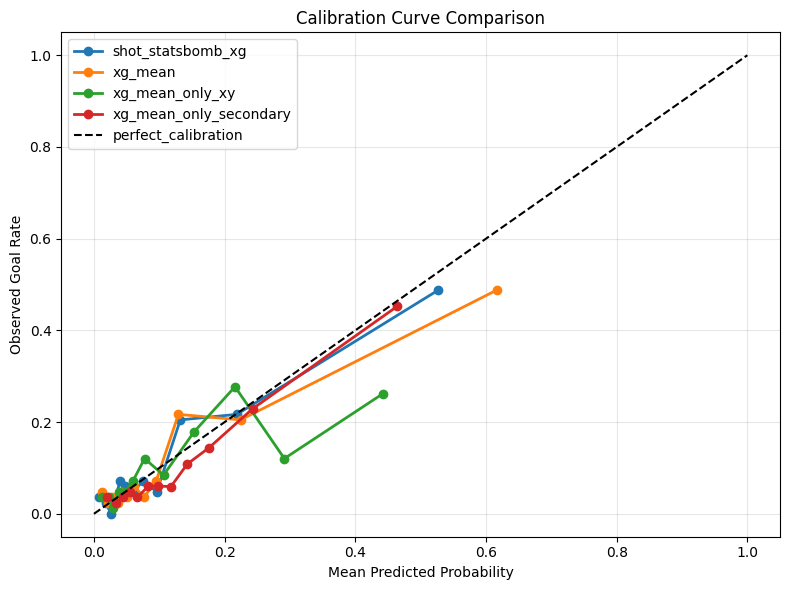

,model,roc_auc,log_loss,brier_score
0,shot_statsbomb_xg,0.802794,0.271565,0.076476
1,xg_mean,0.791885,0.283014,0.079867
2,xg_mean_only_secondary,0.778816,0.286407,0.080665
3,xg_mean_only_xy,0.716731,0.321787,0.093388


In [334]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

required_cols = ["is_goal", "shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy", "xg_mean_only_secondary"]
missing_cols = [c for c in required_cols if c not in df_test.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for calibration/metrics: {missing_cols}")

eval_df = df_test[required_cols].dropna().copy()
eval_df["is_goal"] = eval_df["is_goal"].astype(int)

pred_cols = ["shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy", "xg_mean_only_secondary"]
for c in pred_cols:
    eval_df[c] = np.clip(eval_df[c].astype(float), 1e-6, 1 - 1e-6)

# Calibration plot: all three on same chart
plt.figure(figsize=(8, 6))
for c in pred_cols:
    frac_pos, mean_pred = calibration_curve(eval_df["is_goal"], eval_df[c], n_bins=12, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=c)

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="perfect_calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Goal Rate")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Metrics table: ROC AUC, log loss, brier score
metrics_rows = []
for c in pred_cols:
    metrics_rows.append({
        "model": c,
        "roc_auc": roc_auc_score(eval_df["is_goal"], eval_df[c]),
        "log_loss": log_loss(eval_df["is_goal"], eval_df[c]),
        "brier_score": brier_score_loss(eval_df["is_goal"], eval_df[c]),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
metrics_df

In [335]:
df_test[["shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy", "xg_mean_only_secondary"]]

,shot_statsbomb_xg,xg_mean,xg_mean_only_xy,xg_mean_only_secondary
1501,0.048853,0.081573,0.059260,0.100139
2586,0.120717,0.085480,0.060130,0.126361
2653,0.083350,0.071731,0.074168,0.122501
1055,0.084016,0.126936,0.118252,0.182409
705,0.023258,0.024253,0.025567,0.031794
...,...,...,...,...
4711,0.019543,0.023789,0.019714,0.027601
2313,0.371584,0.146769,0.140744,0.262066
3214,0.009147,0.025205,0.015593,0.028848
2732,0.040308,0.045328,0.075107,0.082368


In [336]:
df_test[["xg_std", "xg_std_only_xy", "xg_std_only_secondary"]]

,xg_std,xg_std_only_xy,xg_std_only_secondary
1501,0.085325,0.107699,0.107197
2586,0.088838,0.099792,0.113543
2653,0.073138,0.119121,0.113874
1055,0.094172,0.147092,0.130933
705,0.052262,0.077027,0.068526
...,...,...,...
4711,0.045597,0.064622,0.053316
2313,0.106263,0.157288,0.152737
3214,0.043272,0.050346,0.052941
2732,0.061856,0.122823,0.098296


In [337]:
print(df_test["xg_std"].mean())
print(df_test["xg_std_only_xy"].mean())
print(df_test["xg_std_only_secondary"].mean())

0.07754013781667433
0.1253741426580481
0.10288365351816207


In [321]:
model_inputs["goalkeeper_shooter_distance"]

array([0.        , 0.        , 0.81215407, ..., 0.        , 0.        ,
       0.27195149], shape=(4000,))

In [11]:
bayesian_xg.fit(df_test, target_col="is_goal")

NotImplementedError: Masked arrays or arrays with `nan` entries are not supported. Pass them directly to `observed` if you want to trigger auto-imputation

In [22]:
# Enforce split equation form everywhere using per-feature missing latents only

def _build_model_split(self, model_inputs: dict = None):
    if model_inputs is None:
        model_inputs = self._model_inputs

    with pm.Model() as model:
        # --- Continuous Values ---
        shot_angle = pm.Data("shot_angle", np.asarray(model_inputs["shot_angle"]))
        shot_distance = pm.Data("shot_distance", np.asarray(model_inputs["shot_distance"]))
        shot_dist_ang = pm.Data("shot_distance_angle", np.asarray(model_inputs["shot_distance_angle"]))
        gk_dist = pm.Data("goalkeeper_shooter_distance", np.asarray(model_inputs["goalkeeper_shooter_distance"]))
        gk_angle = pm.Data("goalkeeper_shooter_angle", np.asarray(model_inputs["goalkeeper_shooter_angle"]))
        gk_dist_ang = pm.Data("goalkeeper_shooter_distance_angle", np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]))
        players_bet = pm.Data("players_between", np.asarray(model_inputs["players_between_shooter_and_goal"]))

        # --- Binary Values ---
        shot_ft = pm.Data("shot_first_time", np.asarray(model_inputs["shot_first_time"]))
        shot_fd = pm.Data("shot_follows_dribble", np.asarray(model_inputs["shot_follows_dribble"]))
        under_p = pm.Data("under_pressure", np.asarray(model_inputs["under_pressure"]))
        open_g = pm.Data("is_open_goal", np.asarray(model_inputs["is_open_goal"]))

        # --- Continuous Missing Masks ---
        shot_angle_m = pm.Data("shot_angle_missing", np.asarray(model_inputs["shot_angle_missing"]))
        shot_dist_m = pm.Data("shot_distance_missing", np.asarray(model_inputs["shot_distance_missing"]))
        shot_dist_ang_m = pm.Data("shot_distance_angle_missing", np.asarray(model_inputs["shot_distance_angle_missing"]))
        gk_dist_m = pm.Data("gk_dist_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]))
        gk_angle_m = pm.Data("gk_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]))
        gk_dist_ang_m = pm.Data("gk_dist_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]))
        players_bet_m = pm.Data("players_between_missing", np.asarray(model_inputs["players_between_shooter_and_goal_missing"]))

        # --- Binary Missing Masks ---
        ft_m = pm.Data("shot_first_time_missing", np.asarray(model_inputs["shot_first_time_missing"]))
        fd_m = pm.Data("shot_follows_dribble_missing", np.asarray(model_inputs["shot_follows_dribble_missing"]))
        up_m = pm.Data("under_pressure_missing", np.asarray(model_inputs["under_pressure_missing"]))
        oog_m = pm.Data("is_open_goal_missing", np.asarray(model_inputs["is_open_goal_missing"]))

        # --- Cat indices ---
        sbp_idx = pm.Data("shot_body_part_idx", np.asarray(model_inputs["cat_idx"]["shot_body_part"]))
        st_idx = pm.Data("shot_technique_idx", np.asarray(model_inputs["cat_idx"]["shot_technique"]))
        at_idx = pm.Data("assist_type_idx", np.asarray(model_inputs["cat_idx"]["assist_type"]))
        ah_idx = pm.Data("assist_height_idx", np.asarray(model_inputs["cat_idx"]["assist_height"]))
        pp_idx = pm.Data("play_pattern_idx", np.asarray(model_inputs["cat_idx"]["play_pattern"]))

        sbp_miss = pm.Data("shot_body_part_missing_data", np.asarray(model_inputs["shot_body_part_missing"]))
        st_miss = pm.Data("shot_technique_missing_data", np.asarray(model_inputs["shot_technique_missing"]))
        at_miss = pm.Data("assist_type_missing_data", np.asarray(model_inputs["assist_type_missing"]))
        ah_miss = pm.Data("assist_height_missing_data", np.asarray(model_inputs["assist_height_missing"]))
        pp_miss = pm.Data("play_pattern_missing_data", np.asarray(model_inputs["play_pattern_missing"]))

        # --- Pressure ---
        dp_idx = pm.Data("pressure_idx", np.asarray(model_inputs["pressure_idx"]))
        dp_m = pm.Data("pressure_missing", np.asarray(model_inputs["pressure_missing"]))

        y = pm.Data("y", np.asarray(model_inputs["y"]))

        # Priors
        alpha = pm.Normal("alpha", mu=-2.2, sigma=1)

        # Continuous betas
        b_shot_angle = pm.Normal("beta_shot_angle", 0, 1)
        b_shot_dist = pm.Normal("beta_shot_distance", 0, 1)
        b_shot_dist_angle = pm.Normal("beta_shot_distance_angle", 0, 1)
        b_gk_dist = pm.Normal("beta_gk_dist", 0, 1)
        b_gk_angle = pm.Normal("beta_gk_angle", 0, 1)
        b_gk_dist_angle = pm.Normal("beta_gk_dist_angle", 0, 1)
        b_players = pm.Normal("beta_players_between", 0, 1)

        # Binary betas
        b_ft = pm.Normal("beta_shot_first_time", 0, 1)
        b_fd = pm.Normal("beta_shot_follows_dribble", 0, 1)
        b_up = pm.Normal("beta_under_pressure", 0, 1)
        b_og = pm.Normal("beta_is_open_goal", 0, 1)

        # Missing-value latent feature realizations x_k^mis (heavy-tailed where appropriate)
        shot_angle_mis_lat = pm.StudentT("shot_angle_mis_lat", nu=3, mu=0, sigma=1)
        shot_dist_mis_lat = pm.StudentT("shot_dist_mis_lat", nu=3, mu=0, sigma=1)
        shot_dist_ang_mis_lat = pm.StudentT("shot_dist_ang_mis_lat", nu=3, mu=0, sigma=1)
        gk_dist_mis_lat = pm.StudentT("gk_dist_mis_lat", nu=3, mu=0, sigma=1)
        gk_angle_mis_lat = pm.StudentT("gk_angle_mis_lat", nu=3, mu=0, sigma=1)
        gk_dist_ang_mis_lat = pm.StudentT("gk_dist_ang_mis_lat", nu=3, mu=0, sigma=1)
        players_mis_lat = pm.StudentT("players_mis_lat", nu=3, mu=0, sigma=1)

        shot_ft_mis_lat = pm.Beta("shot_ft_mis_lat", 2, 2)
        shot_fd_mis_lat = pm.Beta("shot_fd_mis_lat", 2, 2)
        under_p_mis_lat = pm.Beta("under_p_mis_lat", 2, 2)
        open_g_mis_lat = pm.Beta("open_g_mis_lat", 2, 2)

        # Categorical embeddings + explicit missing effects
        sbp_emb = pm.Normal("shot_body_part_emb", 0, 2, shape=model_inputs["n_levels"]["shot_body_part"])
        st_emb = pm.Normal("shot_technique_emb", 0, 2, shape=model_inputs["n_levels"]["shot_technique"])
        at_emb = pm.Normal("assist_type_emb", 0, 2, shape=model_inputs["n_levels"]["assist_type"])
        ah_emb = pm.Normal("assist_height_emb", 0, 2, shape=model_inputs["n_levels"]["assist_height"])
        pp_emb = pm.Normal("play_pattern_emb", 0, 2, shape=model_inputs["n_levels"]["play_pattern"])

        sbp_mis_eff = pm.Normal("shot_body_part_missing_effect", 0, 1)
        st_mis_eff = pm.Normal("shot_technique_missing_effect", 0, 1)
        at_mis_eff = pm.Normal("assist_type_missing_effect", 0, 1)
        ah_mis_eff = pm.Normal("assist_height_missing_effect", 0, 1)
        pp_mis_eff = pm.Normal("play_pattern_missing_effect", 0, 1)

        # Pressure effects
        b_pressure = pm.Normal("beta_pressure_levels", 0, 1, shape=model_inputs["n_pressure_levels"])
        b_pressure_m = pm.Normal("beta_pressure_missing", 0, 1)

        # -------------------------
        # Split equation: observed + missing
        # -------------------------
        eta_obs = 0
        eta_mis = 0

        # continuous
        eta_obs += b_shot_angle * (shot_angle * (1 - shot_angle_m))
        eta_mis += b_shot_angle * (shot_angle_mis_lat * shot_angle_m)

        eta_obs += b_shot_dist * (shot_distance * (1 - shot_dist_m))
        eta_mis += b_shot_dist * (shot_dist_mis_lat * shot_dist_m)

        eta_obs += b_shot_dist_angle * (shot_dist_ang * (1 - shot_dist_ang_m))
        eta_mis += b_shot_dist_angle * (shot_dist_ang_mis_lat * shot_dist_ang_m)

        eta_obs += b_gk_dist * (gk_dist * (1 - gk_dist_m))
        eta_mis += b_gk_dist * (gk_dist_mis_lat * gk_dist_m)

        eta_obs += b_gk_angle * (gk_angle * (1 - gk_angle_m))
        eta_mis += b_gk_angle * (gk_angle_mis_lat * gk_angle_m)

        eta_obs += b_gk_dist_angle * (gk_dist_ang * (1 - gk_dist_ang_m))
        eta_mis += b_gk_dist_angle * (gk_dist_ang_mis_lat * gk_dist_ang_m)

        eta_obs += b_players * (players_bet * (1 - players_bet_m))
        eta_mis += b_players * (players_mis_lat * players_bet_m)

        # binary
        eta_obs += b_ft * (shot_ft * (1 - ft_m))
        eta_mis += b_ft * (shot_ft_mis_lat * ft_m)

        eta_obs += b_fd * (shot_fd * (1 - fd_m))
        eta_mis += b_fd * (shot_fd_mis_lat * fd_m)

        eta_obs += b_up * (under_p * (1 - up_m))
        eta_mis += b_up * (under_p_mis_lat * up_m)

        eta_obs += b_og * (open_g * (1 - oog_m))
        eta_mis += b_og * (open_g_mis_lat * oog_m)

        # pressure and categorical split terms
        eta_obs += b_pressure[dp_idx] * (1 - dp_m)
        eta_mis += b_pressure_m * dp_m

        eta_obs += sbp_emb[sbp_idx] * (1 - sbp_miss)
        eta_mis += sbp_mis_eff * sbp_miss

        eta_obs += st_emb[st_idx] * (1 - st_miss)
        eta_mis += st_mis_eff * st_miss

        eta_obs += at_emb[at_idx] * (1 - at_miss)
        eta_mis += at_mis_eff * at_miss

        eta_obs += ah_emb[ah_idx] * (1 - ah_miss)
        eta_mis += ah_mis_eff * ah_miss

        eta_obs += pp_emb[pp_idx] * (1 - pp_miss)
        eta_mis += pp_mis_eff * pp_miss

        eta = alpha + eta_obs + eta_mis

        p = pm.Deterministic("p", pm.math.sigmoid(eta))
        pm.Bernoulli("y_obs", p=p, observed=y)

    return model


def _posterior_mean_xg_split(self, df: pd.DataFrame, target_col: str, posterior):
    def scalar(name):
        return np.asarray(posterior[name].values).reshape(-1)

    def emb(name):
        arr = np.asarray(posterior[name].values)
        return arr.reshape(-1, *arr.shape[2:])

    inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
    S = scalar("beta_shot_angle").shape[0]
    N = inputs["shot_angle"].shape[0]

    def b(arr):
        return arr.reshape(S, 1)

    def f(vec):
        return vec.reshape(1, N)

    eta_obs = np.zeros((S, N), dtype=float)
    eta_mis = np.zeros((S, N), dtype=float)

    # continuous observed + missing
    eta_obs += b(scalar("beta_shot_angle")) * f(inputs["shot_angle"] * (1 - inputs["shot_angle_missing"]))
    eta_mis += b(scalar("beta_shot_angle")) * f(scalar("shot_angle_mis_lat").mean() * inputs["shot_angle_missing"])

    eta_obs += b(scalar("beta_shot_distance")) * f(inputs["shot_distance"] * (1 - inputs["shot_distance_missing"]))
    eta_mis += b(scalar("beta_shot_distance")) * f(scalar("shot_dist_mis_lat").mean() * inputs["shot_distance_missing"])

    eta_obs += b(scalar("beta_shot_distance_angle")) * f(inputs["shot_distance_angle"] * (1 - inputs["shot_distance_angle_missing"]))
    eta_mis += b(scalar("beta_shot_distance_angle")) * f(scalar("shot_dist_ang_mis_lat").mean() * inputs["shot_distance_angle_missing"])

    eta_obs += b(scalar("beta_gk_dist")) * f(inputs["goalkeeper_shooter_distance"] * (1 - inputs["goalkeeper_shooter_distance_missing"]))
    eta_mis += b(scalar("beta_gk_dist")) * f(scalar("gk_dist_mis_lat").mean() * inputs["goalkeeper_shooter_distance_missing"])

    eta_obs += b(scalar("beta_gk_angle")) * f(inputs["goalkeeper_shooter_angle"] * (1 - inputs["goalkeeper_shooter_angle_missing"]))
    eta_mis += b(scalar("beta_gk_angle")) * f(scalar("gk_angle_mis_lat").mean() * inputs["goalkeeper_shooter_angle_missing"])

    eta_obs += b(scalar("beta_gk_dist_angle")) * f(inputs["goalkeeper_shooter_distance_angle"] * (1 - inputs["goalkeeper_shooter_distance_angle_missing"]))
    eta_mis += b(scalar("beta_gk_dist_angle")) * f(scalar("gk_dist_ang_mis_lat").mean() * inputs["goalkeeper_shooter_distance_angle_missing"])

    eta_obs += b(scalar("beta_players_between")) * f(inputs["players_between_shooter_and_goal"] * (1 - inputs["players_between_shooter_and_goal_missing"]))
    eta_mis += b(scalar("beta_players_between")) * f(scalar("players_mis_lat").mean() * inputs["players_between_shooter_and_goal_missing"])

    # binary observed + missing
    eta_obs += b(scalar("beta_shot_first_time")) * f(inputs["shot_first_time"] * (1 - inputs["shot_first_time_missing"]))
    eta_mis += b(scalar("beta_shot_first_time")) * f(scalar("shot_ft_mis_lat").mean() * inputs["shot_first_time_missing"])

    eta_obs += b(scalar("beta_shot_follows_dribble")) * f(inputs["shot_follows_dribble"] * (1 - inputs["shot_follows_dribble_missing"]))
    eta_mis += b(scalar("beta_shot_follows_dribble")) * f(scalar("shot_fd_mis_lat").mean() * inputs["shot_follows_dribble_missing"])

    eta_obs += b(scalar("beta_under_pressure")) * f(inputs["under_pressure"] * (1 - inputs["under_pressure_missing"]))
    eta_mis += b(scalar("beta_under_pressure")) * f(scalar("under_p_mis_lat").mean() * inputs["under_pressure_missing"])

    eta_obs += b(scalar("beta_is_open_goal")) * f(inputs["is_open_goal"] * (1 - inputs["is_open_goal_missing"]))
    eta_mis += b(scalar("beta_is_open_goal")) * f(scalar("open_g_mis_lat").mean() * inputs["is_open_goal_missing"])

    # pressure
    b_pres = emb("beta_pressure_levels")
    eta_obs += b_pres[:, inputs["pressure_idx"]] * f(1 - inputs["pressure_missing"])
    eta_mis += b(scalar("beta_pressure_missing")) * f(inputs["pressure_missing"])

    # categorical observed + missing
    for col, emb_name, mis_eff_name in [
        ("shot_body_part", "shot_body_part_emb", "shot_body_part_missing_effect"),
        ("shot_technique", "shot_technique_emb", "shot_technique_missing_effect"),
        ("assist_type", "assist_type_emb", "assist_type_missing_effect"),
        ("assist_height", "assist_height_emb", "assist_height_missing_effect"),
        ("play_pattern", "play_pattern_emb", "play_pattern_missing_effect"),
    ]:
        e = emb(emb_name)
        idx = inputs["cat_idx"][col]
        miss = inputs["cat_missing"][col]
        eta_obs += e[:, idx] * f(1 - miss)
        eta_mis += b(scalar(mis_eff_name)) * f(miss)

    eta = b(scalar("alpha")) + eta_obs + eta_mis
    p = sigmoid(eta)
    return p.mean(axis=0), p.std(axis=0)


# Override class methods so the model uses the split equation everywhere
BayesianXg._build_model = _build_model_split
BayesianXg._posterior_mean_xg = _posterior_mean_xg_split

print("BayesianXg updated with split-form eta and per-feature missing latents only.")

BayesianXg updated with split-form eta and per-feature missing latents only.
